<a href="https://colab.research.google.com/github/Alekhya-Therala/Surface-Defect-Detection-in-Ceramic-Tile-Manufacturing-using-computer-Vision/blob/main/GUI_efficient_B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_l

Epoch [1/20] | Train Acc: 67.69% | Val Acc: 53.57% | Test Acc: 55.17%
Epoch [2/20] | Train Acc: 87.69% | Val Acc: 85.71% | Test Acc: 68.97%
Epoch [3/20] | Train Acc: 86.15% | Val Acc: 92.86% | Test Acc: 79.31%
Epoch [4/20] | Train Acc: 90.77% | Val Acc: 100.00% | Test Acc: 82.76%
Epoch [5/20] | Train Acc: 91.54% | Val Acc: 96.43% | Test Acc: 75.86%
Epoch [6/20] | Train Acc: 88.46% | Val Acc: 96.43% | Test Acc: 82.76%
Epoch [7/20] | Train Acc: 90.77% | Val Acc: 100.00% | Test Acc: 86.21%
Epoch [8/20] | Train Acc: 93.08% | Val Acc: 100.00% | Test Acc: 89.66%
Epoch [9/20] | Train Acc: 96.92% | Val Acc: 100.00% | Test Acc: 89.66%
Epoch [10/20] | Train Acc: 93.85% | Val Acc: 96.43% | Test Acc: 89.66%
Epoch [11/20] | Train Acc: 87.69% | Val Acc: 96.43% | Test Acc: 89.66%
Epoch [12/20] | Train Acc: 94.62% | Val Acc: 100.00% | Test Acc: 89.66%
Epoch [13/20] | Train Acc: 93.08% | Val Acc: 100.00% | Test Acc: 89.66%
Epoch [14/20] | Train Acc: 95.38% | Val Acc: 100.00% | Test Acc: 89.66%
Epoch [1

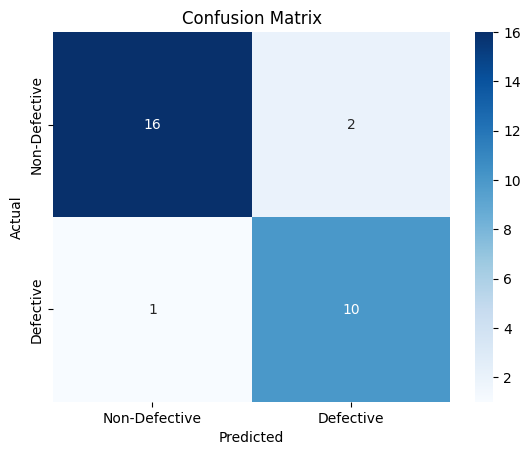

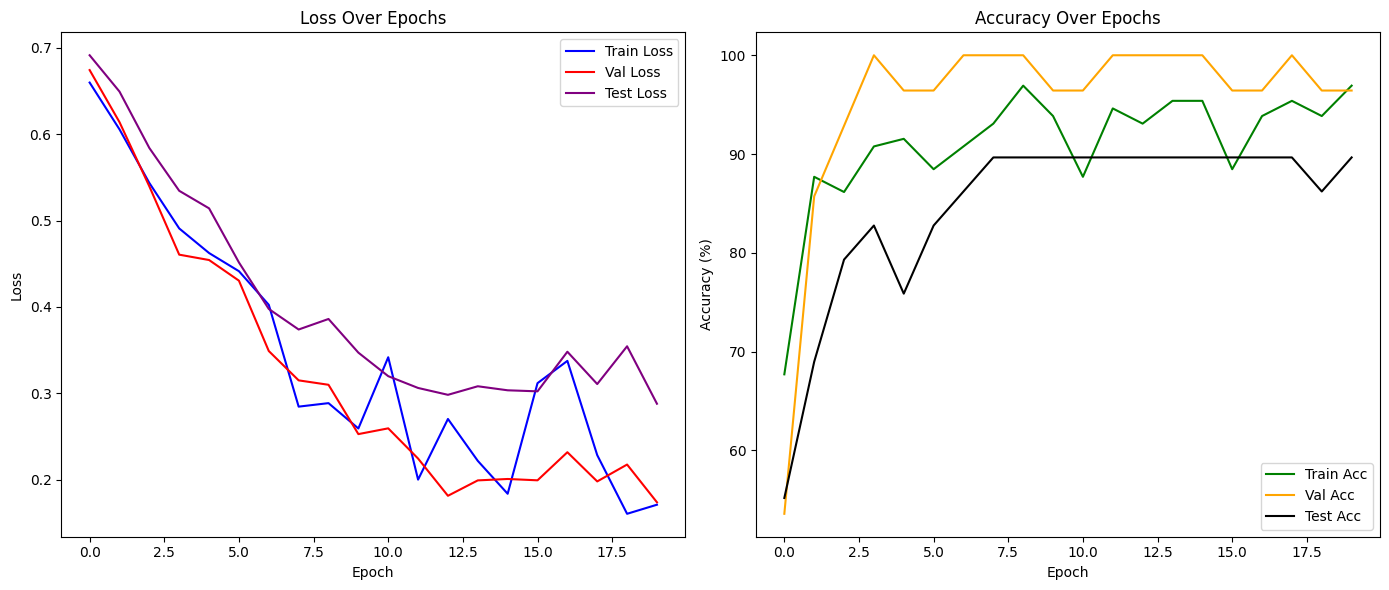

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set seeds
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dataset path
dataset_path = "/content/drive/MyDrive/Tiles_Final"

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load dataset
full_dataset = datasets.ImageFolder(root=dataset_path)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

# Weighted sampling for imbalance
train_labels = [label for _, label in train_dataset]
class_counts = [train_labels.count(i) for i in range(2)]
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Model: EfficientNet-B0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet = models.efficientnet_b0(pretrained=True)
for param in efficientnet.parameters():
    param.requires_grad = False  # Freeze base

# Replace classifier head
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)
efficientnet = efficientnet.to(device)

# Loss, optimizer, scheduler
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(efficientnet.classifier.parameters(), lr=0.0002)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)

# Training function
def train_model(model, train_loader, val_loader, test_loader, epochs=20):
    train_losses, val_losses, test_losses = [], [], []
    train_accs, val_accs, test_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.unsqueeze(1).float())
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).int()
            correct += (preds.squeeze() == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels.unsqueeze(1).float())
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).int()
                val_correct += (preds.squeeze() == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Test
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels.unsqueeze(1).float())
                test_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).int()
                test_correct += (preds.squeeze() == labels).sum().item()
                test_total += labels.size(0)

        test_loss /= len(test_loader)
        test_acc = 100 * test_correct / test_total
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Test Acc: {test_acc:.2f}%")

        scheduler.step(val_loss)

    return train_losses, train_accs, val_losses, val_accs, test_losses, test_accs

# Train EfficientNet-B0
train_losses, train_accs, val_losses, val_accs, test_losses, test_accs = train_model(
    efficientnet, train_loader, val_loader, test_loader, epochs=20
)

# Evaluation
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).int()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.squeeze().cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Defective', 'Defective'],
                yticklabels=['Non-Defective', 'Defective'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

evaluate(efficientnet, test_loader)

# Plotting
def plot_metrics(train_losses, train_accs, val_losses, val_accs, test_losses, test_accs):
    plt.figure(figsize=(14, 6))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss", color="blue")
    plt.plot(val_losses, label="Val Loss", color="red")
    plt.plot(test_losses, label="Test Loss", color="purple")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train Acc", color="green")
    plt.plot(val_accs, label="Val Acc", color="orange")
    plt.plot(test_accs, label="Test Acc", color="black")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_metrics(train_losses, train_accs, val_losses, val_accs, test_losses, test_accs)


In [ ]:
from torchvision import transforms
from PIL import Image

inference_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


In [ ]:
def predict_from_image(image):
    image = inference_transform(image).unsqueeze(0).to(device)
    efficientnet.eval()
    with torch.no_grad():
        output = efficientnet(image)
        prob = torch.sigmoid(output).squeeze().item()
        pred = "Non-Defective" if prob > 0.5 else "Defective"
        return f"{pred} ({prob:.2f})"


In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_from_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Tile Defect Classifier (EfficientNet-B0)",
    description="Upload a tile image to classify it as Defective or Non-Defective."
)

interface.launch(share=True)  # share=True gives you a public link in Colab


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://739b082f7af1503db0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
